# **TRABAJO PRÁCTICO N° 2**

# Predicción de lluvia en Australia 
---
##### 1er Cuatrimestre - Año 2026

| **Integrantes**           | **Legajo** |
|---------------------------|------------|
|Bartomioli Ornella         |(Dni) 47077671 |
| Stefano Candela           | S-5872/6   |
| Vera Nahir Sol            | V-3139/9   |


##### **Docentes:** 


Librerias:

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, mean_absolute_error,
                             mean_squared_error,classification_report,ConfusionMatrixDisplay,roc_curve, auc)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.dummy import DummyClassifier

import warnings


# 1) Carga y análisis de los datos.

In [12]:
# Carga y visuaización del conjunto de Datos
lluvias = pd.read_csv('weatherAUS_2026C1.csv')
lluvias.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [13]:
lluvias = lluvias.rename(columns={
    'Unnamed: 0': 'id',
    'Date': 'fecha',
    'Location': 'ubicacion',
    'MinTemp': 'temp_min',
    'MaxTemp': 'temp_max',
    'Rainfall': 'lluvia',
    'Evaporation': 'evaporacion',
    'Sunshine': 'horas_sol',
    'WindGustDir': 'dir_rafaga_viento',
    'WindGustSpeed': 'vel_rafaga_viento',
    'WindDir9am': 'dir_viento_9am',
    'WindDir3pm': 'dir_viento_3pm',
    'WindSpeed9am': 'vel_viento_9am',
    'WindSpeed3pm': 'vel_viento_3pm',
    'Humidity9am': 'humedad_9am',
    'Humidity3pm': 'humedad_3pm',
    'Pressure9am': 'presion_9am',
    'Pressure3pm': 'presion_3pm',
    'Cloud9am': 'nubes_9am',
    'Cloud3pm': 'nubes_3pm',
    'Temp9am': 'temp_9am',
    'Temp3pm': 'temp_3pm',
    'RainToday': 'llovio_hoy',
    'RainTomorrow': 'llueve_manana',
    'RainfallTomorrow': 'lluvia_manana'})

lluvias.head()

,id,fecha,ubicacion,temp_min,temp_max,lluvia,evaporacion,horas_sol,dir_rafaga_viento,vel_rafaga_viento,...,humedad_3pm,presion_9am,presion_3pm,nubes_9am,nubes_3pm,temp_9am,temp_3pm,llovio_hoy,llueve_manana,lluvia_manana
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [14]:
lluvias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 145412 non-null  int64  
 1   fecha              145412 non-null  object 
 2   ubicacion          145412 non-null  object 
 3   temp_min           143928 non-null  float64
 4   temp_max           144159 non-null  float64
 5   lluvia             142152 non-null  float64
 6   evaporacion        82658 non-null   float64
 7   horas_sol          75616 non-null   float64
 8   dir_rafaga_viento  135096 non-null  object 
 9   vel_rafaga_viento  135159 non-null  float64
 10  dir_viento_9am     134850 non-null  object 
 11  dir_viento_3pm     141186 non-null  object 
 12  vel_viento_9am     143645 non-null  float64
 13  vel_viento_3pm     142351 non-null  float64
 14  humedad_9am        142759 non-null  float64
 15  humedad_3pm        140907 non-null  float64
 16  pr

In [15]:
# Trataamiendo variable 'Date'
lluvias['fecha'] = pd.to_datetime(lluvias['fecha'])
lluvias['mes'] = lluvias['fecha'].dt.month

lluvias = lluvias.drop(columns=['fecha'])

Se transformó la variable fecha a datetime para poder trabajar adecuadamente con ella y extraer la información correspondiente al mes de cada observación.

In [16]:
# Eliminación Variable 'id'
lluvias = lluvias.drop(columns=['id'])

Se eliminó la variable id, ya que actúa únicamente como un identificador y no aporta información para el análisis.

 **Análisis de Variables:**

In [17]:
lluvias.describe()

,temp_min,temp_max,lluvia,evaporacion,horas_sol,vel_rafaga_viento,vel_viento_9am,vel_viento_3pm,humedad_9am,humedad_3pm,presion_9am,presion_3pm,nubes_9am,nubes_3pm,temp_9am,temp_3pm,lluvia_manana,mes
count,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135159.000000,143645.000000,142351.000000,142759.000000,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000,142153.000000,145412.000000
mean,12.196528,23.223064,2.361516,5.468616,7.611241,40.036668,14.067277,18.661899,68.861521,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360,2.361242,6.399747
std,6.417956,7.135927,8.479338,4.193871,3.785612,13.648259,8.936768,8.865457,19.062866,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072,8.479084,3.427820
min,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000,0.000000,1.000000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,12.000000,57.000000,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000,3.000000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,38.000000,13.000000,18.000000,69.900000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000,6.000000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000,9.000000
max,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000,371.000000,12.000000


In [18]:
# Verificación de las localidades
ubicaciones = lluvias['ubicacion'].unique()
print(ubicaciones)

['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond' 'Sydney' 'SydneyAirport'
 'WaggaWagga' 'Williamtown' 'Wollongong' 'Canberra' 'Tuggeranong'
 'MountGinini' 'Ballarat' 'Bendigo' 'Sale' 'MelbourneAirport' 'Melbourne'
 'Mildura' 'Nhil' 'Portland' 'Watsonia' 'Dartmoor' 'Brisbane' 'Cairns'
 'GoldCoast' 'Townsville' 'Adelaide' 'MountGambier' 'Nuriootpa' 'Woomera'
 'Albany' 'Witchcliffe' 'PearceRAAF' 'PerthAirport' 'Perth' 'SalmonGums'
 'Walpole' 'Hobart' 'Launceston' 'AliceSprings' 'Darwin' 'Katherine'
 'Uluru']


Analizamos las ubicaciones registradas con el objetivo de verificar su correcta codificación y asegurar la ausencia de valores duplicados o inconsistencias en su representación.

In [19]:
# Valores posibles para llovio_hoy :
lluvias['llovio_hoy'].unique()

array(['No', 'Yes', nan], dtype=object)

In [20]:
# Valores posibles para llueve_manana :
lluvias['llueve_manana'].unique()

array(['No', 'Yes', nan], dtype=object)

In [21]:
lluvias['horas_sol'].value_counts().sort_index()

horas_sol
0.0     2359
0.1      542
0.2      521
0.3      433
0.4      326
        ... 
14.0      15
14.1       6
14.2       2
14.3       4
14.5       1
Name: count, Length: 145, dtype: int64

**Valores Faltantes:**

**Variables temporales: Datetime y numéricas discretas.**

* fecha: fecha de la observación meteorológica. (2007-11-01 a 2017-06-24)
* dia: día de la semana de la observación. Valores del 1 (lunes) al 7 (domingo).
* mes: mes de la observación. Valores del 1 al 12.
* anio: año de la observación. Valores del 2007 al 2017.

**Variable de Ubicación: Categórica.**
* ubicacion: ciudad de Australia donde se registró el clima (49 ciudades distintas).

**Variables de temperatura: Numéricas continuas.**
* temp_min: temperatura mínima en el día en °C. (-9.7 a 34.1)
* temp_max: temperatura máxima en el día en °C. (-5.1 a 49.1)
* temp_9am: temperatura a las 9am en °C. (-8.0 a 39.8)
* temp_3pm: temperatura a las 3pm en °C. (-5.8 a 47.0)

**Variables de viento:
Categóricas:**
* dir_rafaga_viento: dirección de la ráfaga de viento más fuerte (16 direcciones).
* dir_viento_9am y dir_viento_3pm: dirección del viento a las 9am y 3pm (16 direcciones posibles).

**Numéricas continuas:**
* vel_viento_9am: velocidad del viento a las 9am en km/h. (0.0 a 130.0)
* vel_viento_3pm: velocidad del viento a las 3pm en km/h. (0.0 a 86.0)
* vel_rafaga_viento: velocidad de la ráfaga de viento máxima en km/h. (6.0 a 135.0)

**Variables de humedad y presión: Numéricas continuas.**
* humedad_9am y humedad_3pm: porcentaje de humedad a las 9am y 3pm. (0.0 a 100.0)
* presion_9am y presion_3pm: presión atmosférica medida en hPa a las 9am y 3pm. (980.3 a 1041.2) y (977.4 a 1039.8)

**Variables del clima: Numéricas continuas / discretas.**
* nubes_9am y nubes_3pm: nivel de nubosidad. (0.0 a 9.0)
* horas_sol: cantidad de horas de sol en el día. (0.0 a 14.5)
* evaporacion: nivel de evaporación aparente en mm. (0.0 a 145.0)
* lluvia: cantidad de agua caida acumulada durante el día en mm. (0.0 a 371.0)

**Variables de hecho (o categóricas de decisión):**
* llovio_hoy: variable categórica que indica si el día de hoy se superó 1 mm de lluvia. (No / Yes)
* llovera_manana: variable categórica objetivo que indica si lloverá al día siguiente. (No / Yes)
* lluvia_manana: cantidad de lluvia registrada al día siguiente en mm. (0.0 a 371.0)

In [23]:
# Eliminacion de las observaciones con la variable objetivo Nan:
lluvias = lluvias[lluvias['llueve_manana'].notna()]

Eliminamos los registros que no contaban con la variable a predecir.

In [24]:
# Cantidad de nulos por columna:
cant = lluvias.isnull().sum()

# Porcentaje de nulos por olumna:
porc_nul = (lluvias.isnull().sum() / len(lluvias)) * 100 

tabla_nulos = pd.DataFrame({
    'Cantidad_nulos': cant,
    'Porcentaje_nulos': porc_nul
})

# Ordeanar
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje_nulos', ascending=False)

tabla_nulos

,Cantidad_nulos,Porcentaje_nulos
horas_sol,67785,47.684537
evaporacion,60812,42.779259
nubes_3pm,57076,40.151105
nubes_9am,53641,37.734694
presion_9am,14010,9.855578
presion_3pm,13977,9.832364
dir_viento_9am,10009,7.041005
dir_rafaga_viento,9328,6.561944
vel_rafaga_viento,9268,6.519736
dir_viento_3pm,3776,2.656293


Se observa una gran cantidad de valores faltantes, luego de hacer la división train/test los trabajaremos.

In [25]:
# Lista de columnas donde decidimos eliminar las filas con nulos
col_nan = ['dir_viento_9am', 'dir_rafaga_viento', 'vel_rafaga_viento', 'humedad_3pm', 'dir_viento_3pm', 'temp_3pm', 'llovio_hoy', 
    'lluvia', 'llueve_manana', 'lluvia_manana', 'vel_viento_3pm', 'humedad_9am', 'vel_viento_9am', 'temp_9am', 'temp_min', 'temp_max']

lluvias = lluvias.dropna(subset=col_nan).copy()
print(f"Registros después de la limpieza: {lluvias.shape[0]}")

Registros después de la limpieza: 121757


Eliminamos los registros co valores faltantes en las variables que presentaban menos proporcion de nan.

In [26]:
lluvias['llueve_manana'].value_counts(normalize=True) * 100

llueve_manana
No     77.923241
Yes    22.076759
Name: proportion, dtype: float64

El dataset no se encuentra balanceado, ya que predominan los registros correspondientes a días en los que no llueve. El desbalance de clases puede afectar el rendimiento del modelo de clasificación, provocando que tienda a predecir con mayor frecuencia la clase mayoritaria. Métricas como accuracy pueden resultar engañosas, por lo que es importante analizar también precisión, recall y matriz de confusión.

# 2) División Conjuntos Train y Test:

In [28]:
# Separamos X e y:
X = lluvias.drop(['llueve_manana','lluvia_manana'], axis=1)
y = lluvias['llueve_manana']

In [29]:
# Dividir train y test:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

X_train = X_train.copy()
X_test = X_test.copy()

# 3) Limpieza y tratamiento:

### Tratamiento de Valores Faltantes:

In [30]:
# Cantidad de nulos por columna:
cant = lluvias.isnull().sum()

# Porcentaje de nulos por olumna:
porc_nul = (X_train.isnull().sum() / len(lluvias)) * 100 

tabla_nulos = pd.DataFrame({
    'Cantidad_nulos': cant,
    'Porcentaje_nulos': porc_nul
})

# Ordeanar
tabla_nulos = tabla_nulos.sort_values(by='Porcentaje_nulos', ascending=False)

tabla_nulos.head(7)

,Cantidad_nulos,Porcentaje_nulos
horas_sol,55045,36.149872
evaporacion,49877,32.786616
nubes_3pm,46727,30.724312
nubes_9am,45385,29.862759
presion_9am,8826,5.833751
presion_3pm,8775,5.796792
humedad_3pm,0,0.000000


Se decidió imputar los valores faltantes de las variables horas_sol, evaporación, nubes_3pm, nubes_9am, presion_9am y presion_3pm, ya que todas presentan mayor proporción de observaciones nulas. Utilizamos la media, considerando la ubicación y el mes como criterios de agrupación, con el objetivo representar la estacion y la geográfica de los datos.

In [31]:
def imputar_por_ubi_y_mes(datos, columna):
    """
    Imputa valores nulos de una columna usando la media agrupada por ubicacion y mes.
    """

    datos[columna] =datos[columna].fillna( datos.groupby(['ubicacion', 'mes'])[columna].transform('mean'))

    # Caso de no tener registros para esa configuracion
    datos[columna] = datos[columna].fillna(datos[columna].mean())

    return datos


In [32]:
# Imputación X_train:
col_imputar = ['horas_sol','evaporacion','nubes_3pm','nubes_9am','presion_9am','presion_3pm']

for col in col_imputar:
    X_train = imputar_por_ubi_y_mes(X_train, col)

In [33]:
# Imputación X_test con los valores de X_train
for col in col_imputar:

    # medias del train
    medias_grupo = X_train.groupby(['ubicacion', 'mes'])[col].mean()
    media_global = X_train[col].mean()

    # PASO A: imputación por grupo
    X_test[col] = X_test.apply(
        lambda row: medias_grupo.get((row['ubicacion'], row['mes']), None)
        if pd.isnull(row[col]) else row[col],
        axis=1)

    # PASO B: imputación global
    X_test[col] = X_test[col].fillna(media_global)


Para el resto de las variables, que presentaban menos del 10% de registros faltantes, se optó por eliminar las observaciones correspondientes.

### Análisis de distribuciones:

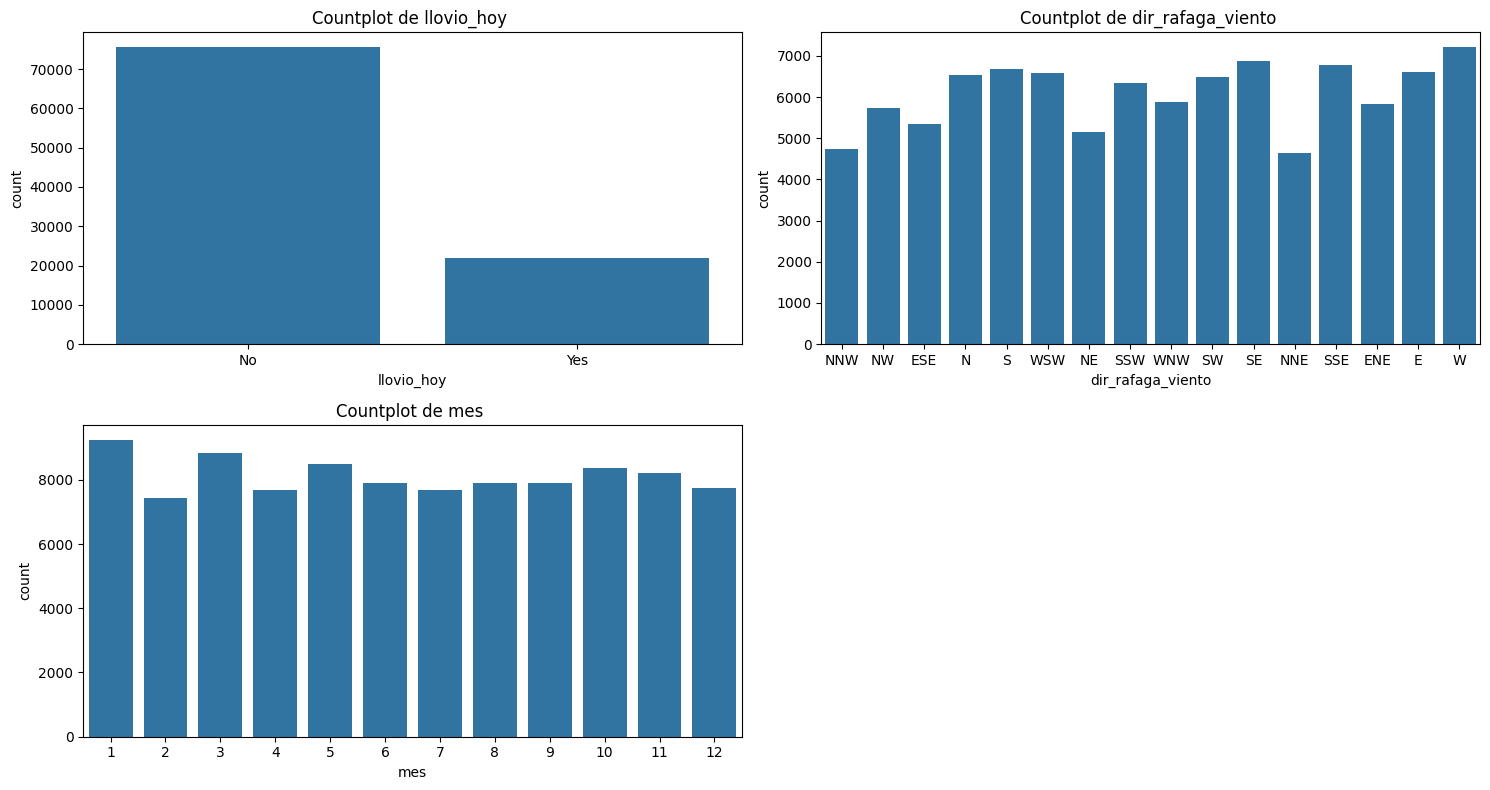

In [34]:
# COUNTPLO:
cols_cat = ['llovio_hoy','dir_rafaga_viento','mes']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols_cat):
    plt.subplot(2, 2, i+1)
    sns.countplot(data=X_train, x=col)
    plt.title(f"Countplot de {col} ")

plt.tight_layout()
plt.show()

#VER COMO PONEMOS LAS UBIVACIONES,PERO LAS PRIMAS 10

En base al countplot con las variables llovio_hoy, dir_rafaga_viento y mes, podemos observar:

Para la variable mes, las observaciones se distribuyen de manera uniforme a lo largo de los doce meses, dando a entender que existe la misma cantidad de datos para todas las estaciones climaticas sin sesgos temporales.

Para dir_rafaga_viento la distribución demuestra un comportamiento variado y bastante equilibrado entre los 16 puntos, lo que indica que no hay una unica direccion del viento que domine todo el dataset.

Por ultimo en llovio_hoy el grafico expone un fuerte desbalance de clases, evidenciando que en la gran mayoria de los dias registrados no hubo precipitaciones significativas.

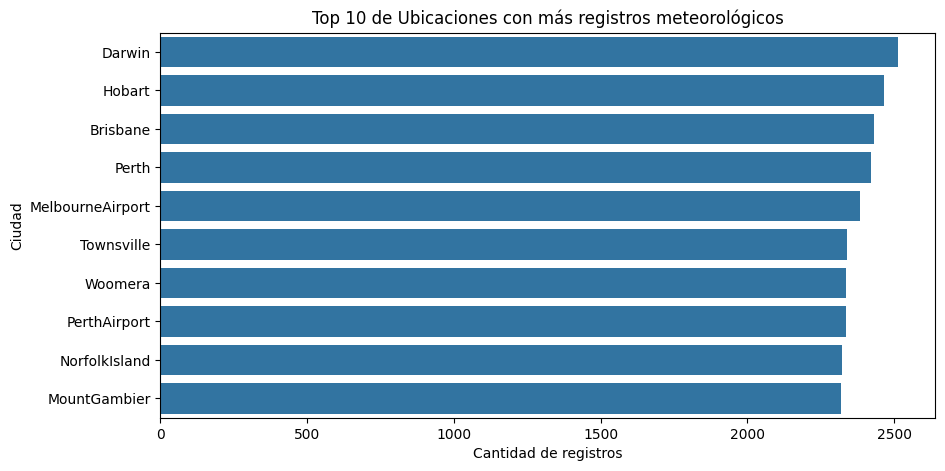

In [37]:
#  Countplot con solo el Top 10 de ubicaciones
plt.figure(figsize=(10, 5))

top_10_ubicaciones = X_train['ubicacion'].value_counts().head(10).index
sns.countplot(data=X_train, y='ubicacion', order=top_10_ubicaciones)

plt.title("Top 10 de Ubicaciones con más registros meteorológicos")
plt.xlabel("Cantidad de registros")
plt.ylabel("Ciudad")
plt.show()

Hacemos un countplot aparte con la variable ubicacion pues es categorica.

Podemos observar que el top 10 de las ubicaciones con mas registros estan dentro del intervalo de 2000 y 2500.

Siendo el top 1 Darwing y el top 10 MountGambier.

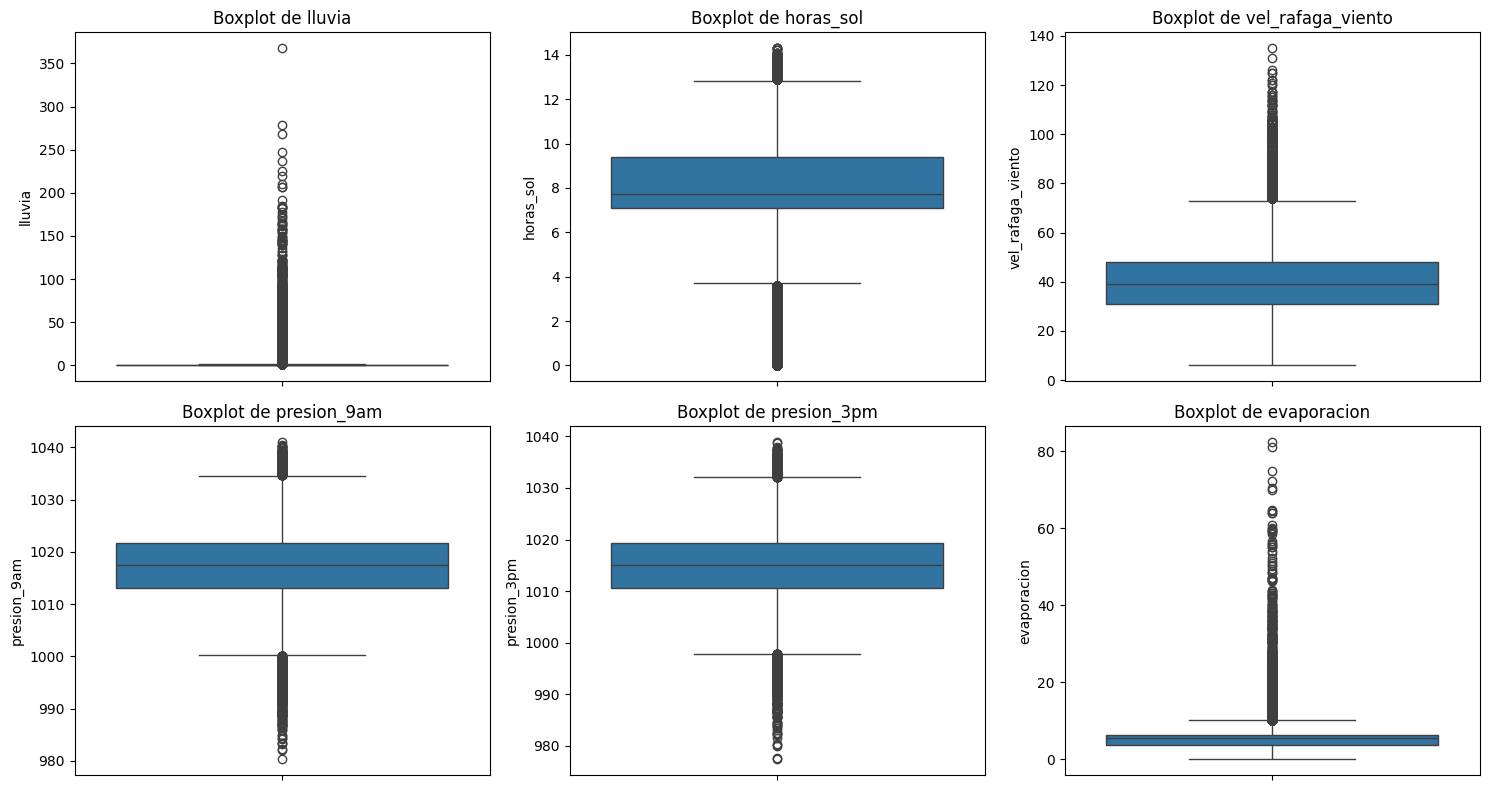

In [38]:
# BOXPLOTS
cols_num = ['lluvia','horas_sol', 'vel_rafaga_viento', 'presion_9am','presion_3pm','evaporacion']

plt.figure(figsize=(15,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 3, i+1)
    sns.boxplot(data=X_train, y=col)
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

A partir de los diagramas de caja se observan valores atípicos principalmente en las variables lluvia, vel_rafaga_viento y evaporacion, donde existen registros considerablemente superiores al comportamiento general de los datos.

La presion_9am y presion_3pm tienen similitudes en cuanto a su distribucion.

Y que el 50% de los valores centrales de horas_sol se encuentran entre 6 y 10

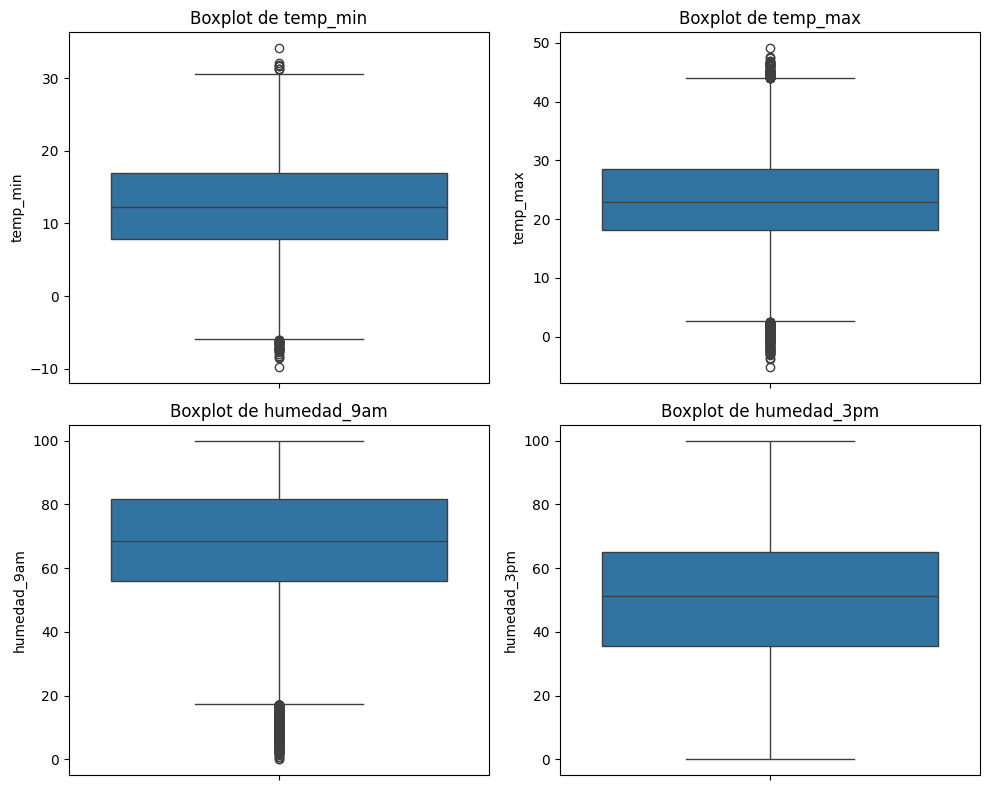

In [40]:
cols_num = ['temp_min', 'temp_max','humedad_9am', 'humedad_3pm']

plt.figure(figsize=(10,8))

for i, col in enumerate(cols_num):
    plt.subplot(2, 2, i+1)
    sns.boxplot(data=X_train, y=col)
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

Viendo los boxplots de temp_min y temp_max, vemos que presentan distribuciones bastante simétricas, reflejando la variabilidad climatica sin una presencia significativa de valores atipicos severos.

 Por otro lado, al analizar las variables de humedad, se evidencia un claro contraste a lo largo del día: la humedad_9am es mas alta y concentrada en valores elevados, presentando algunos outliers en el extremo inferior, mientras que hacia la tarde, humedad_3pm, la distribución se desplaza hacia valores menores.

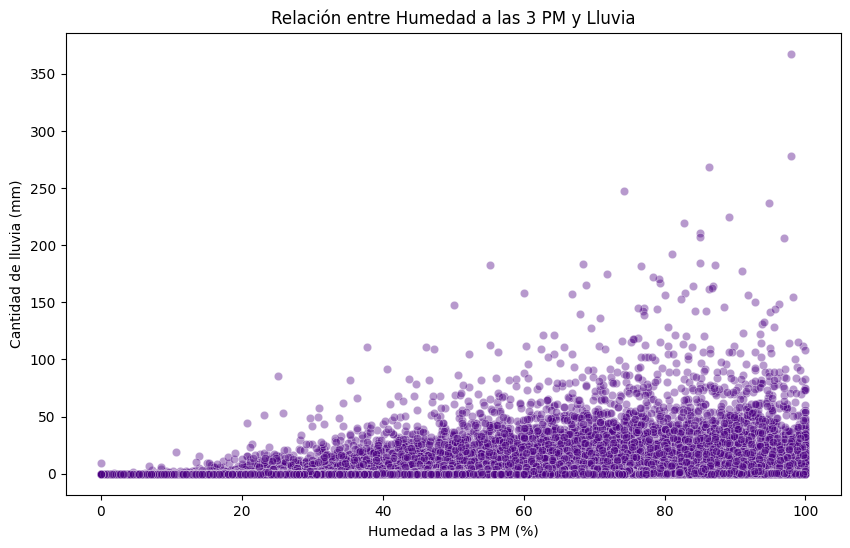

In [39]:
# SCATTERPLOT (humedad_3pm vs lluvia)

plt.figure(figsize=(10,6))
sns.scatterplot( data=X_train, x='humedad_3pm', y='lluvia', alpha=0.4, color='indigo')
plt.title('Relación entre Humedad a las 3 PM y Lluvia')
plt.xlabel('Humedad a las 3 PM (%)')
plt.ylabel('Cantidad de lluvia (mm)')
plt.show()

Se muestra una relación positiva entre la humedad a las 3 PM y la cantidad de lluvia. A medida que aumenta la humedad, también tienden a incrementarse las precipitaciones registradas. Sin embargo, la dispersión de los puntos indica que la relación no es completamente lineal y que intervienen otros factores climáticos en la ocurrencia de lluvia.

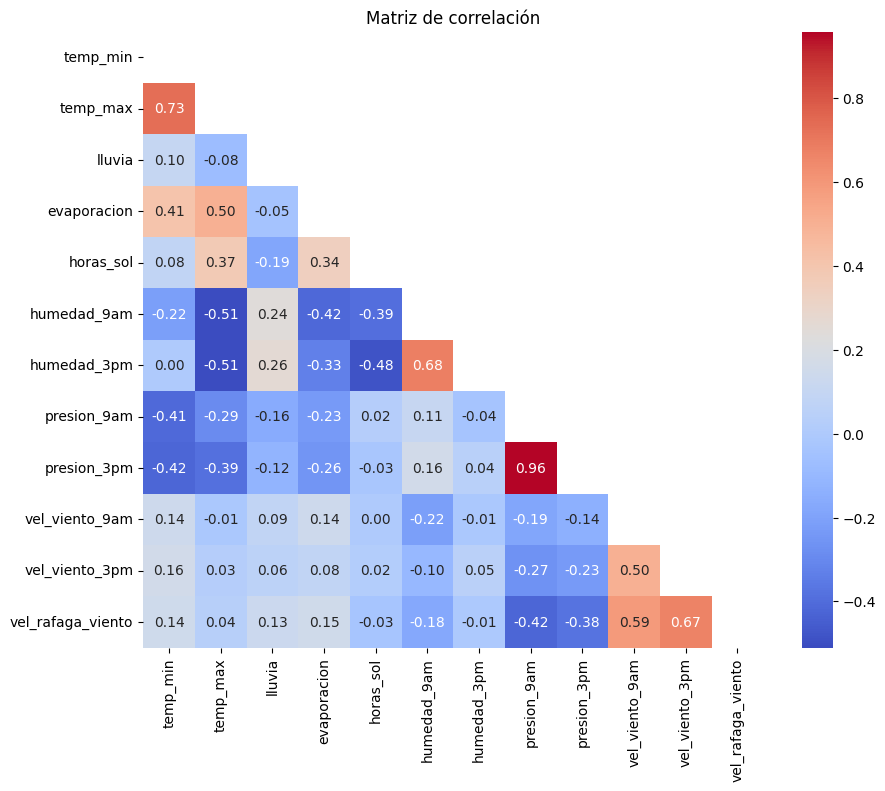

In [41]:
#MATRIZ DE CORRELACIÓN:
vars_corr = ['temp_min','temp_max','lluvia','evaporacion','horas_sol','humedad_9am','humedad_3pm',
             'presion_9am','presion_3pm','vel_viento_9am','vel_viento_3pm','vel_rafaga_viento']
corr = X_train[vars_corr].corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Matriz de correlación')
plt.show()

Se detecto una posible de multicolinealidad, destacándose la relación entre presion_9am y presion_3pm con un coeficiente de 0.96. Para evitar redundancias que afecten la estabilidad de los coeficientes de la Regresión Logística, se decidió eliminar la variable presion_9am. Asimismo, se mantuvo un seguimiento sobre las variables de temperatura y viento, priorizando aquellas con mayor capacidad descriptiva según el análisis visual.

In [42]:
cols_a_eliminar = ['presion_9am', 'temp_min', 'humedad_9am', 'vel_viento_9am']

X_train = X_train.drop(columns=cols_a_eliminar)
X_test = X_test.drop(columns=cols_a_eliminar)

print(f"Nuevas dimensiones - Train: {X_train.shape}, Test: {X_test.shape}")

Nuevas dimensiones - Train: (97405, 18), Test: (24352, 18)


### Codificación de variables categóricas:

In [43]:
# Lueve_hoy:
X_train['llovio_hoy'] = X_train['llovio_hoy'].map({'No':0, 'Yes':1})
X_test['llovio_hoy'] = X_test['llovio_hoy'].map({'No':0, 'Yes':1})

In [44]:
# Lueve_manana:
y_train = y_train.map({'No':0, 'Yes':1})
y_test =  y_test.map({'No':0, 'Yes':1})

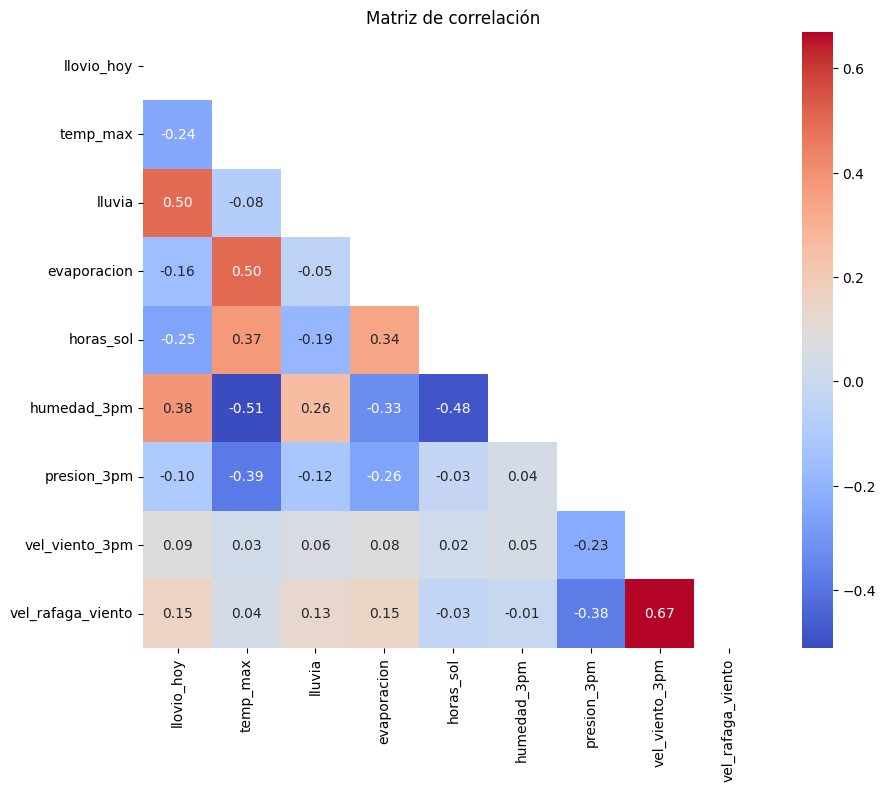

In [45]:
#MATRIZ DE CORRELACIÓN:
vars_corr = ['llovio_hoy','temp_max','lluvia','evaporacion','horas_sol','humedad_3pm'
             ,'presion_3pm','vel_viento_3pm','vel_rafaga_viento']
corr = X_train[vars_corr].corr()

plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr,mask=mask,annot=True,cmap='coolwarm',fmt='.2f')

plt.title('Matriz de correlación')
plt.show()

In [48]:
# One-Hot Encoding:
cols_cat = ['ubicacion','dir_rafaga_viento','dir_viento_9am','dir_viento_3pm']

X_train = pd.get_dummies(X_train, columns=cols_cat, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_cat, drop_first=True)

#Alinear
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

Las variables categóricas fueron transformadas a variables numéricas para utilizarlas en el modelo de regresión logística. La variable 'llovio_hoy' fue codificada como binaria, mientras que las variables 'ubicacion','dir_rafaga_viento','dir_viento_9am'y'dir_viento_3pm' fueron transformadas con One-Hot Encoding.

### Estandarización/Escalado:

In [49]:
cols_num = ['temp_max', 'lluvia', 'evaporacion', 'horas_sol', 'humedad_3pm', 'presion_3pm', 'vel_viento_3pm', 'vel_rafaga_viento','nubes_3pm','temp_3pm']

scaler = StandardScaler()
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])
X_test[cols_num] = scaler.transform(X_test[cols_num])

# Regresión Logística:

In [50]:
# Inicializar y entrenar un modelo de regresión logística
modelo_log = LogisticRegression(max_iter=1000,random_state=42)
modelo_log.fit(X_train, y_train)

# Predicción
y_pred = modelo_log.predict(X_test)

# Probabilidad:
y_prob = modelo_log.predict_proba(X_test)[:,1]

In [51]:
# Generar el reporte de métricas
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     18976
           1       0.73      0.52      0.61      5376

    accuracy                           0.85     24352
   macro avg       0.80      0.73      0.76     24352
weighted avg       0.84      0.85      0.84     24352



In [52]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))

Accuracy: 0.8509362680683311
Precision: 0.7267532467532467
Recall: 0.5204613095238095
F1-score: 0.606546715803165


Accuracy (0.850): Es la exactitud general. Significa que el modelo acertó el 85% de todas sus predicciones

Precision (0.727): Significa que el modelo tiene un 71% de acierto y un 29% de falsas alarmas.

Recall (0.52): De todos los dias en los q llovio, el modelo solo fue capaz de detectar el 52%. Basicamente, se le escapa casi la mitad de la lluvia (falsos negativos), lo cual es el punto más débil del modelo

F1-score (0.606): Es el balance general entre la precisión y el recall. El F1-score se ve arrastrado hacia abajo dando un 60.1%. Este numero demuestra que el modelo no esta equilibrado y que le cuesta mucho predecir correctamente la clase minoritaria (dias de lluvia).


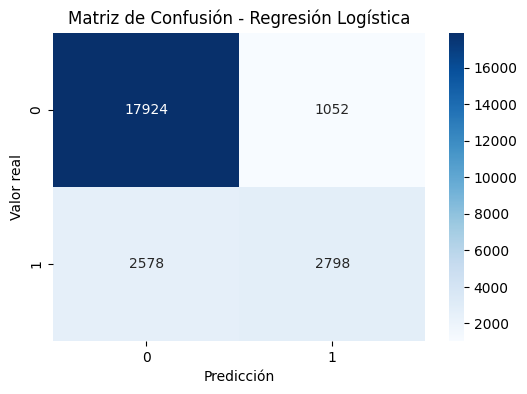

In [53]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

Falso negativo y falso positivo:

In [54]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 17924
False Positives: 1052
False Negatives: 2578
True Positives: 2798


Falso positivo (FP): El modelo predice lluvia para el día siguiente, pero en realidad no llueve.

Falso negativo (FN):El modelo predice que no lloverá, pero finalmente sí llueve.

El modelo logra identificar correctamente muchos dias sin lluvia(17925) y tambien una buena cantidad de dias lluviosos(2.800).

Sin embargo, todavía comete algunos errores: en ciertos casos predice lluvia cuando finalmente no llueve (falsos positivos), y en otros no logra anticipar lluvias reales (falsos negativos).

In [55]:
# Probabilidades
y_prob = modelo_log.predict_proba(X_test)[:,1]

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Área bajo la curva
roc_auc = auc(fpr, tpr)

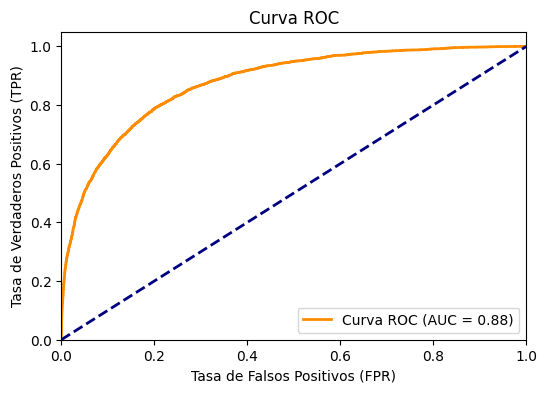

In [56]:
# Grafico la curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.show()

La regresión logística alcanza un AUC cercano a 0.88, mostrando una muy buena capacidad para diferenciar días lluviosos de días sin lluvia.

 Sin embargo, al contrastar este valor con el bajo rendimiento obtenido en el recall (52%), se concluye que la limitación no se debe a una falta de capacidad predictiva de las variables, sino a que el umbral de decisión por defecto resulta demasiado estricto frente al desbalance de las clases.

In [57]:
roc_auc

0.8758219577486348

In [58]:
fpr, tpr, thresholds

(array([0.        , 0.        , 0.        , ..., 0.99341273, 0.99341273,
        1.        ], shape=(5242,)),
 array([0.00000000e+00, 1.86011905e-04, 1.22767857e-02, ...,
        9.99813988e-01, 1.00000000e+00, 1.00000000e+00], shape=(5242,)),
 array([           inf, 9.97869054e-01, 9.83592692e-01, ...,
        3.23003793e-03, 3.22561747e-03, 6.99361400e-04], shape=(5242,)))

### Mejor Umbral

El umbral (threshold) representa el valor de probabilidad a partir del cual el modelo clasifica un caso como positivo (lluvia). Por defecto suele utilizarse 0.5, es decir, si la probabilidad predicha es mayor o igual a 50%, el modelo predice lluvia.

Sin embargo, 0.5 no siempre es el mejor umbral. El valor óptimo depende del problema y del equilibrio deseado entre precisión y recall. En problemas meteorológicos suele ser importante reducir los falsos negativos, ya que no predecir una lluvia real puede generar mayores consecuencias.

In [59]:
#UMBRAL
thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0
best_f1 = 0

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)

    score = f1_score(y_test, y_pred_t)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Mejor umbral:", best_threshold)
print("Mejor F1-score:", best_f1)

Mejor umbral: 0.30000000000000004
Mejor F1-score: 0.6428694305866162


Se evaluaron distintos valores de threshold(umbral) para determinar cuál ofrecía el mejor equilibrio entre precisión y recall utilizando el F1-score como criterio de evaluación.

El mejor resultado se obtuvo con un umbral de 0.30, alcanzando un F1-score de aproximadamente 0.64.

Indicando que, para este problema, un umbral menor a 0.5 permite detectar una mayor cantidad de días lluviosos, mejorando el equilibrio general del modelo.

Por lo tanto, se concluye que el valor por defecto de 0.5 no necesariamente es el más adecuado para este caso, ya que un umbral más bajo mejora el desempeño en la detección de lluvia.

# 3.  Implementación del Modelo Base (Dummy Classifier)

In [60]:
modelo_base = DummyClassifier(strategy="most_frequent")
modelo_base.fit(X_train, y_train)

y_pred_base = modelo_base.predict(X_test)

y_probs_base = modelo_base.predict_proba(X_test)[:, 1]


print("--- MÉTRICAS DEL MODELO BASE (BASELINE) ---")
print(classification_report(y_test, y_pred_base))


--- MÉTRICAS DEL MODELO BASE (BASELINE) ---
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     18976
           1       0.00      0.00      0.00      5376

    accuracy                           0.78     24352
   macro avg       0.39      0.50      0.44     24352
weighted avg       0.61      0.78      0.68     24352



c:\Users\Sol\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sol\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sol\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

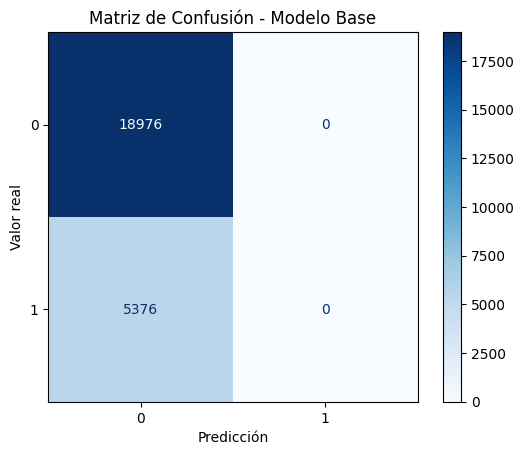

In [61]:
# Graficar Matriz de Confusión del Modelo Base
ConfusionMatrixDisplay.from_estimator(modelo_base, X_test, y_test, cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title('Matriz de Confusión - Modelo Base')
plt.show()

In [62]:
# Predicciones modelo base
y_pred_base = modelo_base.predict(X_test)

# Matriz de confusión
cm_base = confusion_matrix(y_test, y_pred_base)

tn, fp, fn, tp = cm_base.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 18976
False Positives: 0
False Negatives: 5376
True Positives: 0


El modelo base logró identificar correctamente los días sin lluvia, pero no pudo detectar ningún día lluvioso. Esto pasa porque siempre predice la clase más frecuente (‘No lluvia’), por lo que no aprende realmente patrones del clima y funciona solo como referencia para comparar con modelos más avanzados.

In [63]:
# Probabilidades
y_prob_base = modelo_base.predict_proba(X_test)[:,1]

# ROC
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)

auc_base = auc(fpr_base, tpr_base)

print("AUC modelo base:", auc_base)

AUC modelo base: 0.5


Que el AUC del modelo base sea 0.5 refleja matematicamente lo mencionado anteriormente: el modelo no tiene ninguna capacidad para discriminar o separar las clases. Al predecir siempre de forma automatica la clase mas frecuente, su tasa de aciertos es equivalente a adivinar el clima mediante el azar

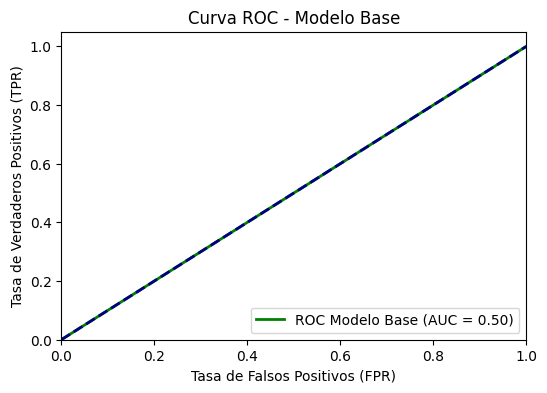

In [64]:
# Curva ROC - Modelo Base

plt.figure(figsize=(6, 4))
plt.plot(fpr_base, tpr_base, color='green', lw=2, label='ROC Modelo Base (AUC = %0.2f)' % auc_base)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelo Base')
plt.legend(loc="lower right")
plt.show()

La regresión logística supera ampliamente al modelo base, demostrando capacidad para aprender patrones climáticos relevantes y realizar predicciones significativamente mejores que un clasificador aleatorio o trivial.

Probamos distintos thresholds solamente en la regresión logística, porque el modelo base básicamente siempre predice la opción más común y no aporta probabilidades útiles para analizar distintos umbrales.

**¿El modelo logró un buen fitting?**

Consideramos que el modelo logró un buen fitting, ya que obtuvo métricas significativamente superiores al modelo base. La regresión logística alcanzó un AUC cercano a 0.88, mostrando una buena capacidad para distinguir entre días con lluvia y sin lluvia.

Además, el modelo no presentó resultados artificialmente perfectos luego de eliminar variables con posible data leakage, lo que indica un comportamiento más realista y una mejor capacidad de generalización sobre datos no vistos.